In [1]:
# What type of ML problem is this?
# --> Unsupervised Learning → Clustering Problem
# Becoz
# No target variable
# We want to group customers based on similarity

In [3]:
# Why is clustering suitable?
# Because:
# We want to segment customers
# No predefined labels (like buyer/non-buyer)
# Goal is customer grouping for marketing
# Clustering helps:
# Identify customer behavior patterns
# Create personalized marketing strategies

In [4]:
# Data Preprocessing

In [5]:
# Using Age, Annual_Income, Spending_Score
# CustomerID (just identifier)

In [6]:
# Why Feature Scaling?
# K-Means uses Euclidean distance.
# Income values (15000–62000) are much larger than:
# Spending score (1–100)
# Without scaling:
# Income dominates clustering.
# So scaling is mandatory.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings("ignore")

In [21]:
df = pd.read_csv("customer_segmentation.csv")
print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (20, 4)
   CustomerID  Age  Annual_Income  Spending_Score
0           1   19          15000              39
1           2   21          18000              81
2           3   20          20000               6
3           4   23          22000              77
4           5   31          24000              40


In [22]:
# Remove CustomerID
X = df.drop("CustomerID", axis=1)

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [23]:
inertia = [] #to find out best k

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

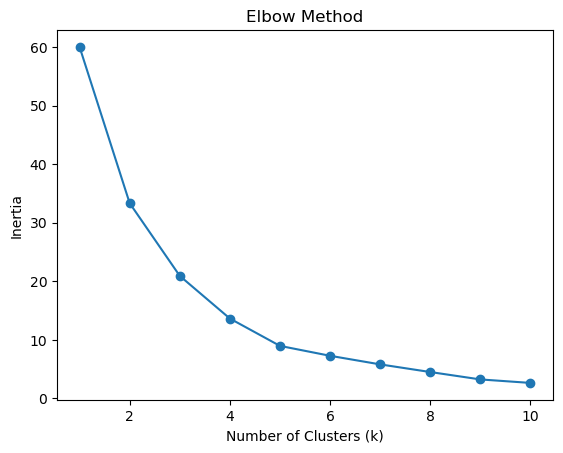

In [24]:
plt.figure()
plt.plot(range(1, 11), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.show()

In [25]:
# ============================
# Train KMeans (Assume K 3 based on elbow)
# ============================

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)

print("\nCustomers per Cluster:")
print(df["Cluster"].value_counts())


Customers per Cluster:
Cluster
0    9
2    7
1    4
Name: count, dtype: int64


<Figure size 640x480 with 0 Axes>

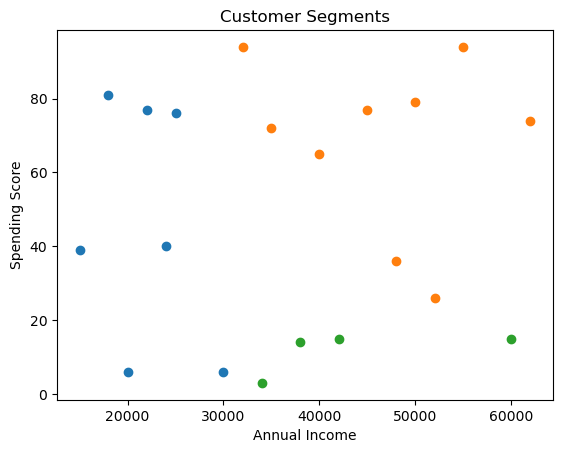

In [26]:
# ============================
# Cluster Visualization (Income vs Spending)
# ============================
plt.figure()
plt.figure()
for cluster in df["Cluster"].unique():
    cluster_data = df[df["Cluster"] == cluster]
    plt.scatter(cluster_data["Annual_Income"],
                cluster_data["Spending_Score"])

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segments")
plt.show()

In [27]:
# ============================
# Cluster Centers
# ============================

centers = scaler.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(centers, columns=X.columns)
print("\nCluster Centers (Original Scale):")
print(centers_df)


Cluster Centers (Original Scale):
         Age  Annual_Income  Spending_Score
0  29.000000   46555.555556       68.555556
1  60.250000   43500.000000       11.750000
2  24.428571   22000.000000       46.428571
